In [6]:
#LOADING REQUIREMENTS
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import kaggle

In [7]:
#DOWNLOAD DATASET
def download_iris_dataset():
    """Download Iris dataset from Kaggle using API"""
    print("Downloading Iris dataset from Kaggle...")

    kaggle.api.dataset_download_files(
        'uciml/iris',
        path='./data',
        unzip=True
    )

    print("Dataset downloaded successfully!")
    return './data/Iris.csv'

In [8]:
#LOAD AND EXPLORE DATA
def load_and_explore_data(file_path):
    """Load the dataset and display basic information"""
    df = pd.read_csv(file_path)

    print("\n" + "="*50)
    print("DATASET OVERVIEW")
    print("="*50)
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(df.head())
    print(f"\nData types:")
    print(df.dtypes)
    print(f"\nMissing values:")
    print(df.isnull().sum())

    return df

In [9]:
#PREPROCESS DATA
def preprocess_data(df):
    """Handle missing values and encode labels"""
    print("\n" + "="*50)
    print("PREPROCESSING DATA")
    print("="*50)

    if 'Id' in df.columns:
        df = df.drop('Id', axis=1)
        print("Dropped 'Id' column")

    initial_shape = df.shape
    print(f"\nInitial shape: {initial_shape}")

    missing_before = df.isnull().sum().sum()
    print(f"Total missing values: {missing_before}")

    if missing_before > 0:
        for column in df.columns:
            if df[column].isnull().sum() > 0:
                if df[column].dtype in ['float64', 'int64']:
                    df[column].fillna(df[column].median(), inplace=True)
                    print(f"Filled missing values in '{column}' with median")
                else:
                    df[column].fillna(df[column].mode()[0], inplace=True)
                    print(f"Filled missing values in '{column}' with mode")
    else:
        print("No missing values found")

    df = df.dropna()
    print(f"Shape after handling missing values: {df.shape}")

    label_column = 'Species'
    if label_column in df.columns:
        print(f"\nEncoding '{label_column}' column...")
        print(f"Original classes: {df[label_column].unique()}")

        label_encoder = LabelEncoder()
        df['Species_Encoded'] = label_encoder.fit_transform(df[label_column])

        print(f"Encoded classes: {df['Species_Encoded'].unique()}")
        print(f"Mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

    return df, label_encoder

In [10]:
#TRAIN DECISION TREE CLASSIFIER
def train_decision_tree(X_train, X_test, y_train, y_test):
    """Train a Decision Tree Classifier"""
    print("\n" + "="*50)
    print("TRAINING DECISION TREE CLASSIFIER")
    print("="*50)

    dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)

    print("Training model...")
    dt_classifier.fit(X_train, y_train)
    print("Training completed!")

    y_pred = dt_classifier.predict(X_test)

    return dt_classifier, y_pred

In [11]:
#EVALUATE MODEL
def evaluate_model(y_test, y_pred, label_encoder):
    """Evaluate model using accuracy, precision, and recall"""
    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")

    
    import seaborn as sns
    import matplotlib.pyplot as plt

    print("\nDetailed classification report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\n" + "="*50)
    print("PER-CLASS METRICS")
    print("="*50)

    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)

    for i, class_name in enumerate(label_encoder.classes_):
        print(f"\n{class_name}:")
        print(f"  Precision: {precision_per_class[i]:.4f}")
        print(f"  Recall:    {recall_per_class[i]:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall
    }


IRIS CLASSIFICATION PIPELINE
Dataset URL: https://www.kaggle.com/datasets/uciml/iris
Dataset downloaded successfully!

DATASET OVERVIEW

Shape: (150, 6)

Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

First few rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Data types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
Pet

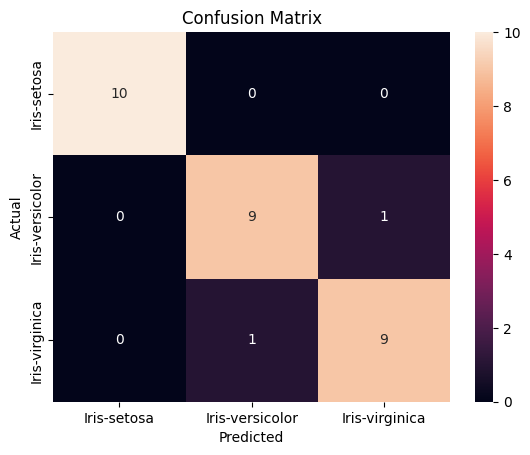


PER-CLASS METRICS

Iris-setosa:
  Precision: 1.0000
  Recall:    1.0000

Iris-versicolor:
  Precision: 0.9000
  Recall:    0.9000

Iris-virginica:
  Precision: 0.9000
  Recall:    0.9000

PIPELINE COMPLETED SUCCESSFULLY!


In [12]:
#MAIN PIPELINE FUNCTION
def main():
    """Main function to run the entire pipeline"""
    print("\n" + "="*50)
    print("IRIS CLASSIFICATION PIPELINE")
    print("="*50)

    os.makedirs('./data', exist_ok=True)

    file_path = download_iris_dataset()

    df = load_and_explore_data(file_path)

    df, label_encoder = preprocess_data(df)

    feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
    X = df[feature_columns]
    y = df['Species_Encoded']

    print("\n" + "="*50)
    print("SPLITTING DATA")
    print("="*50)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")

    model, y_pred = train_decision_tree(X_train, X_test, y_train, y_test)

    metrics = evaluate_model(y_test, y_pred, label_encoder)

    print("\n" + "="*50)
    print("PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*50)

    return model, metrics


if __name__ == "__main__":
    main()